In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1780584040.544074    2645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780584043.110794    2645 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780584052.303852    2645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
dataset_path = "PlantDoc-Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2578 files belonging to 2 classes.
Using 2063 files for training.


E0000 00:00:1780584066.686353    2645 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 2578 files belonging to 2 classes.
Using 515 files for validation.


In [3]:
class_names = train_ds.class_names

print("Classes:")
for i, cls in enumerate(class_names):
    print(i, cls)

num_classes = len(class_names)

print("\nTotal Classes:", num_classes)

Classes:
0 test
1 train

Total Classes: 2


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
dataset_path = "PlantDoc-Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2578 files belonging to 2 classes.
Using 2063 files for training.
Found 2578 files belonging to 2 classes.
Using 515 files for validation.


In [6]:
class_names = train_ds.class_names

print("Classes:")
for i, cls in enumerate(class_names):
    print(i, cls)

num_classes = len(class_names)

print("\nTotal Classes:", num_classes)

Classes:
0 test
1 train

Total Classes: 2


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [9]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [10]:
model = models.Sequential([
    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8938 - loss: 0.3781 - val_accuracy: 0.9087 - val_loss: 0.3040
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9094 - loss: 0.2961 - val_accuracy: 0.9087 - val_loss: 0.2863
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.9118 - loss: 0.2825 - val_accuracy: 0.9087 - val_loss: 0.2872
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.9094 - loss: 0.2781 - val_accuracy: 0.9087 - val_loss: 0.2966
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.9069 - loss: 0.2671 - val_accuracy: 0.9126 - val_loss: 0.2850
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9103 - loss: 0.2668 - val_accuracy: 0.9087 - val_loss: 0.2926
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9157 - loss: 0.2571 - val_accuracy: 0.8971 - val_loss: 0.2924
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.9118 - loss: 0.2480 - val_accuracy: 0.9029 - v

In [13]:
model.save("crop_disease_model.h5")

print("Model Saved!")

Model Saved!


In [14]:
from tensorflow.keras.preprocessing import image

img_path = "/content/test_leaf.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Disease:", predicted_class)
print("Confidence:", round(confidence,2), "%")

FileNotFoundError: [Errno 2] No such file or directory: '/content/test_leaf.jpg'

In [15]:
from tensorflow.keras.preprocessing import image

img_path = "PlantDoc-Dataset/train/Bell_pepper leaf spot/03.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Disease:", predicted_class)
print("Confidence:", round(confidence,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Disease: train
Confidence: 97.89 %


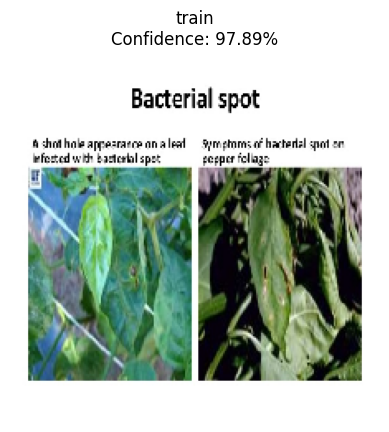

In [16]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

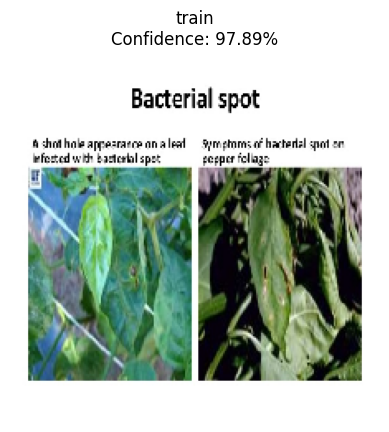

In [17]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

In [18]:
model.savd("/home/ubuntu/sdog-disease-model.h5")

AttributeError: 'Sequential' object has no attribute 'savd'

In [19]:
model.savd("/home/ubuntu/PlantDoc-Dataset-model.h5")

AttributeError: 'Sequential' object has no attribute 'savd'

In [20]:
model.save("/home/ubuntu/PlantDoc-Dataset-model.h5")

In [21]:
model.save("/home/ubuntu/PlantDoc-Dataset-model.keras")

In [22]:
import os

print(os.path.exists("/home/ubuntu/PlantDoc-Dataset-model.keras"))

True


In [1]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

NameError: name 'plt' is not defined

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1780638306.810608    1873 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780638308.400985    1873 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780638313.801027    1873 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
dataset_path = "archive (2).zip"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

NotADirectoryError: [Errno 20] Not a directory: 'archive (2).zip'